# Building Block Classification and Library Enumeration — Test Results


## Summary
1. Input: 16 building blocks — 10 from ChEMBL (MW<250, Ro5 compliant) + 6 simple reference compounds added to verify the tool
2. Classification: Each BB assigned to one or more reactivity classes based on functional group SMARTS matching
3. Synthonization: Each classified BB converted into synthon representations encoding its reactive center
4. Enumeration: Synthons combined to generate new drug-like molecules

In [1]:
# Imports
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem.Draw import MolsToGridImage
from IPython.display import display
print('Imports OK')

Imports OK


---
## Step 1: Input Building Blocks

16 building blocks were used as input:
- **10 ChEMBL compounds** filtered by: small molecule, MW <250 Da, Ro5 violations = 0
- **6 simple reference compounds** added (simple amines and carboxylic acids whose expected reaction products are easy to verify)

In [2]:
print("=== INPUT BUILDING BLOCKS (16 total) ===\n")
print(f"{'ID':<30} {'SMILES'}")
print("-" * 80)
with open('/home/nubar/Downloads/Internship_Chemoinfo/03_synthon/input_bbs/test_extended.smi') as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) >= 2:
            print(f"{parts[1]:<30} {parts[0]}")

=== INPUT BUILDING BLOCKS (16 total) ===

ID                             SMILES
--------------------------------------------------------------------------------
CHEMBL3272776                  C(Nc1c2c(ncn1)[nH]nc2)(NCC=C)=O
CHEMBL181824                   c1(c(ccc(c1)OC)OC)n1c(ccc1)CCN
CHEMBL3274502                  C1(Cc2c(ccc(c2)CC(=O)O)O1)(C)C
CHEMBL176800                   C(C)(NCCCNCCCCN)=O
CHEMBL3785716                  c1(c2c(cccc2)n(c1C)C)c1cnc(N)s1
CHEMBL3451509                  C(c1ccc(nc1)OC)(Nc1nncs1)=O
CHEMBL3805876                  C1(c2cc3c(ccc(c3)F)n2CC(N1O)=O)=O
CHEMBL4104098                  C1([C@]2([C@@H](C(CC=C)=O)CC[C@H]2CC1=O)O)=C
CHEMBL1871798                  c1(ccc(cc1)Cl)Cc1ccc(nn1)O
CHEMBL4060932                  C1([C@H]2[C@](CC(C=1)=O)(CC[C@@H](C(C)(C)O)C2)C)C
SIMPLE_BENZYLAMINE             NCc1ccccc1
SIMPLE_ANILINE                 Nc1ccccc1
SIMPLE_METHYLAMINE             CN
SIMPLE_BENZOICACID             OC(=O)c1ccccc1
SIMPLE_ACETICACID              CC(=O)

---
## Step 2: BB Classification Results

The Synt-On classifier was run on all 16 BBs. Each BB was checked against 38 reaction SMARTS patterns and assigned to matching reactivity classes.

**Result:** 15 out of 16 BBs were successfully classified. One compound (CHEMBL3805876) was not classified — it does not contain a functional group matching any of Synt-On's 38 reaction classes.

The classified BBs are shown below with their assigned class(es) and number of generated synthons.

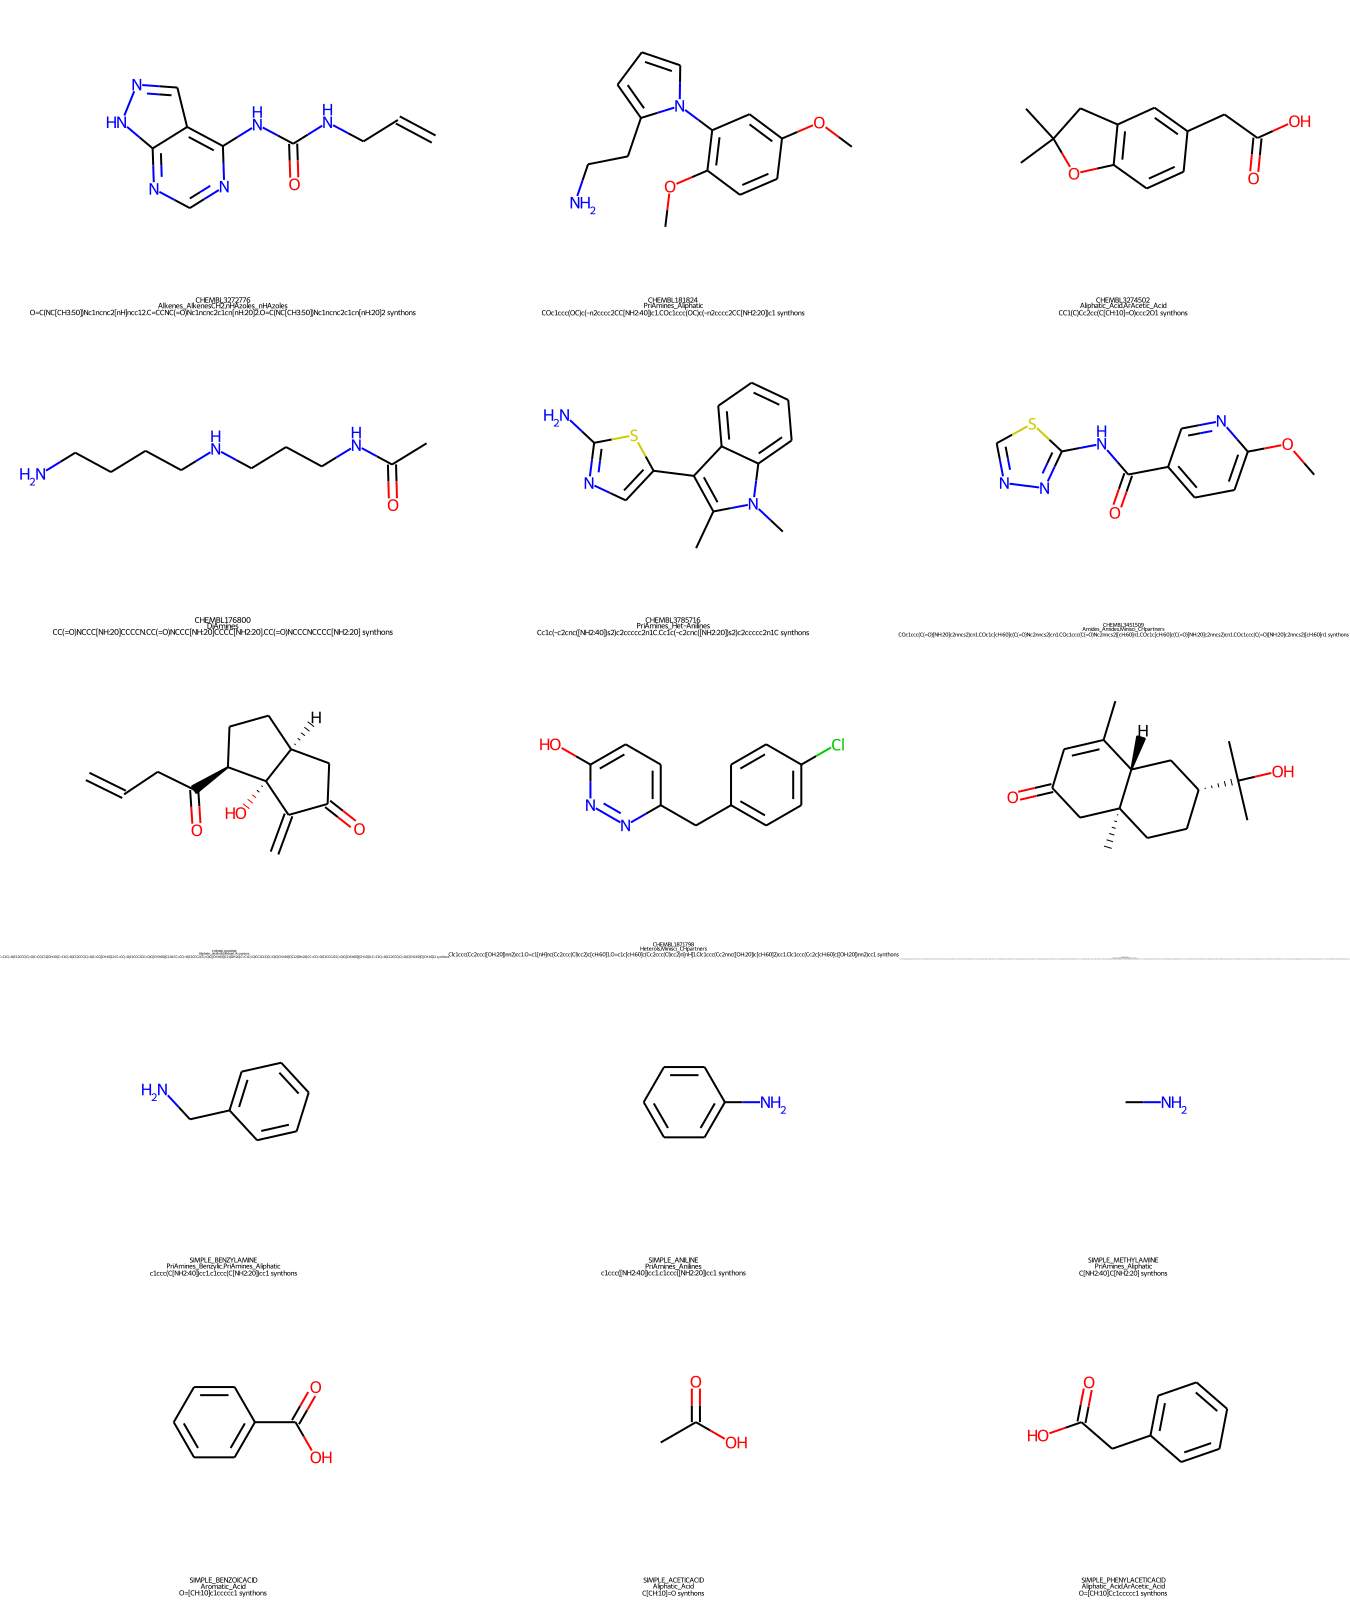


15 BBs classified successfully


In [3]:
# Draw classified BBs as molecule grid
bbmode_path = '/home/nubar/Downloads/Internship_Chemoinfo/03_synthon/outputs/test_extended_noRo2_BBmode.smi'

mols, legends = [], []
with open(bbmode_path) as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) >= 4:
            mol = Chem.MolFromSmiles(parts[0])
            if mol:
                mols.append(mol)
                # Shorten long class names for display
                cls = parts[2].replace('PrimaryAmines_', '').replace('Reagents_', '').replace('Alcohols_', '').replace('Acid_', '')
                legends.append(f"{parts[1]}\n{cls}\n{parts[3]} synthons")

img = MolsToGridImage(mols, molsPerRow=3, subImgSize=(450, 320), legends=legends)
out_path = '/home/nubar/Downloads/Internship_Chemoinfo/04_results/classified_bbs_extended.png'
with open(out_path, 'wb') as f:
    f.write(img.data)
display(img)
print(f'\n{len(mols)} BBs classified successfully')

In [4]:
# Text summary of classification
print(f"{'ID':<30} {'Class':<45} {'N Synthons'}")
print("-" * 90)
with open(bbmode_path) as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) >= 4:
            print(f"{parts[1]:<30} {parts[2]:<45} {parts[3]}")

print("\nNot classified:")
with open('/home/nubar/Downloads/Internship_Chemoinfo/03_synthon/outputs/test_extended_noRo2_NotClassified') as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) >= 2:
            print(f"  {parts[1]:<30} {parts[0]}")

ID                             Class                                         N Synthons
------------------------------------------------------------------------------------------
CHEMBL3272776                  Alkenes_AlkenesCH2,nHAzoles_nHAzoles          O=C(NC[CH3:50])Nc1ncnc2[nH]ncc12.C=CCNC(=O)Nc1ncnc2c1cn[nH:20]2.O=C(NC[CH3:50])Nc1ncnc2c1cn[nH:20]2
CHEMBL181824                   PrimaryAmines_PriAmines_Aliphatic             COc1ccc(OC)c(-n2cccc2CC[NH2:40])c1.COc1ccc(OC)c(-n2cccc2CC[NH2:20])c1
CHEMBL3274502                  Acid_Aliphatic_Acid,Acid_ArAcetic_Acid        CC1(C)Cc2cc(C[CH:10]=O)ccc2O1
CHEMBL176800                   Reagents_DiAmines                             CC(=O)NCCC[NH:20]CCCCN.CC(=O)NCCC[NH:20]CCCC[NH2:20].CC(=O)NCCCNCCCC[NH2:20]
CHEMBL3785716                  PrimaryAmines_PriAmines_Het-Anilines          Cc1c(-c2cnc([NH2:40])s2)c2ccccc2n1C.Cc1c(-c2cnc([NH2:20])s2)c2ccccc2n1C
CHEMBL3451509                  Amides_Amides,Reagents_Minisci_CHpartners     COc1ccc(C(

---
## Step 3: Synthon Generation

Each classified BB was converted into one or more synthons. 

### Simple reference compounds — synthons
These are shown first because they are easiest to interpret:
- Simple **amines** produce synthons with a tagged `[NH2]` group
- Simple **carboxylic acids** produce aldehyde-like synthons — the COOH is represented as CHO encoding the electrophilic carbon center

In [5]:
print("=== SYNTHONS FROM SIMPLE REFERENCE COMPOUNDS ===\n")
with open('/home/nubar/Downloads/Internship_Chemoinfo/03_synthon/outputs/test_extended_noRo2_Synthmode.smi') as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) >= 3 and parts[1].startswith('SIMPLE'):
            print(f"BB:      {parts[1]}")
            print(f"Synthon: {parts[0]}")
            print(f"Class:   {parts[2]}")
            print("-" * 55)

=== SYNTHONS FROM SIMPLE REFERENCE COMPOUNDS ===

BB:      SIMPLE_BENZYLAMINE
Synthon: c1ccc(C[NH2:40])cc1
Class:   PrimaryAmines_PriAmines_Aliphatic+PrimaryAmines_PriAmines_Benzylic
-------------------------------------------------------
BB:      SIMPLE_BENZYLAMINE
Synthon: c1ccc(C[NH2:20])cc1
Class:   PrimaryAmines_PriAmines_Aliphatic+PrimaryAmines_PriAmines_Benzylic
-------------------------------------------------------
BB:      SIMPLE_ANILINE
Synthon: c1ccc([NH2:40])cc1
Class:   PrimaryAmines_PriAmines_Anilines
-------------------------------------------------------
BB:      SIMPLE_ANILINE
Synthon: c1ccc([NH2:20])cc1
Class:   PrimaryAmines_PriAmines_Anilines
-------------------------------------------------------
BB:      SIMPLE_METHYLAMINE
Synthon: C[NH2:40]
Class:   PrimaryAmines_PriAmines_Aliphatic
-------------------------------------------------------
BB:      SIMPLE_METHYLAMINE
Synthon: C[NH2:20]
Class:   PrimaryAmines_PriAmines_Aliphatic
------------------------------------

In [6]:
# All synthons
print("=== ALL SYNTHONS (59 total) ===\n")
print(f"{'Synthon SMILES':<45} {'BB ID':<25} {'Class'}")
print("-" * 110)
with open('/home/nubar/Downloads/Internship_Chemoinfo/03_synthon/outputs/test_extended_noRo2_Synthmode.smi') as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) >= 3:
            print(f"{parts[0]:<45} {parts[1]:<25} {parts[2]}")

=== ALL SYNTHONS (59 total) ===

Synthon SMILES                                BB ID                     Class
--------------------------------------------------------------------------------------------------------------
O=C(NC[CH3:50])Nc1ncnc2[nH]ncc12              CHEMBL3272776             Alkenes_AlkenesCH2
C=CCNC(=O)Nc1ncnc2c1cn[nH:20]2                CHEMBL3272776             nHAzoles_nHAzoles
O=C(NC[CH3:50])Nc1ncnc2c1cn[nH:20]2           CHEMBL3272776             nHAzoles_nHAzoles+Alkenes_AlkenesCH2
COc1ccc(OC)c(-n2cccc2CC[NH2:40])c1            CHEMBL181824              PrimaryAmines_PriAmines_Aliphatic
COc1ccc(OC)c(-n2cccc2CC[NH2:20])c1            CHEMBL181824              PrimaryAmines_PriAmines_Aliphatic
CC1(C)Cc2cc(C[CH:10]=O)ccc2O1                 CHEMBL3274502             Acid_ArAcetic_Acid+Acid_Aliphatic_Acid
CC(=O)NCCC[NH:20]CCCCN                        CHEMBL176800              Reagents_DiAmines
CC(=O)NCCC[NH:20]CCCC[NH2:20]                 CHEMBL176800              Rea

---
## Step 4: Library Enumeration

The enumeration script combined compatible synthons from the 16 BBs to generate new molecules.

**Parameters used:**
- MW range of products: 100 – 500 Da
- Desired number of new molecules: 100
- Cores used: 12
- No Ro2 filter applied at synthon stage

**Result:** 108 new molecules generated from 16 building blocks.

Total enumerated products: 108
Showing first 12:



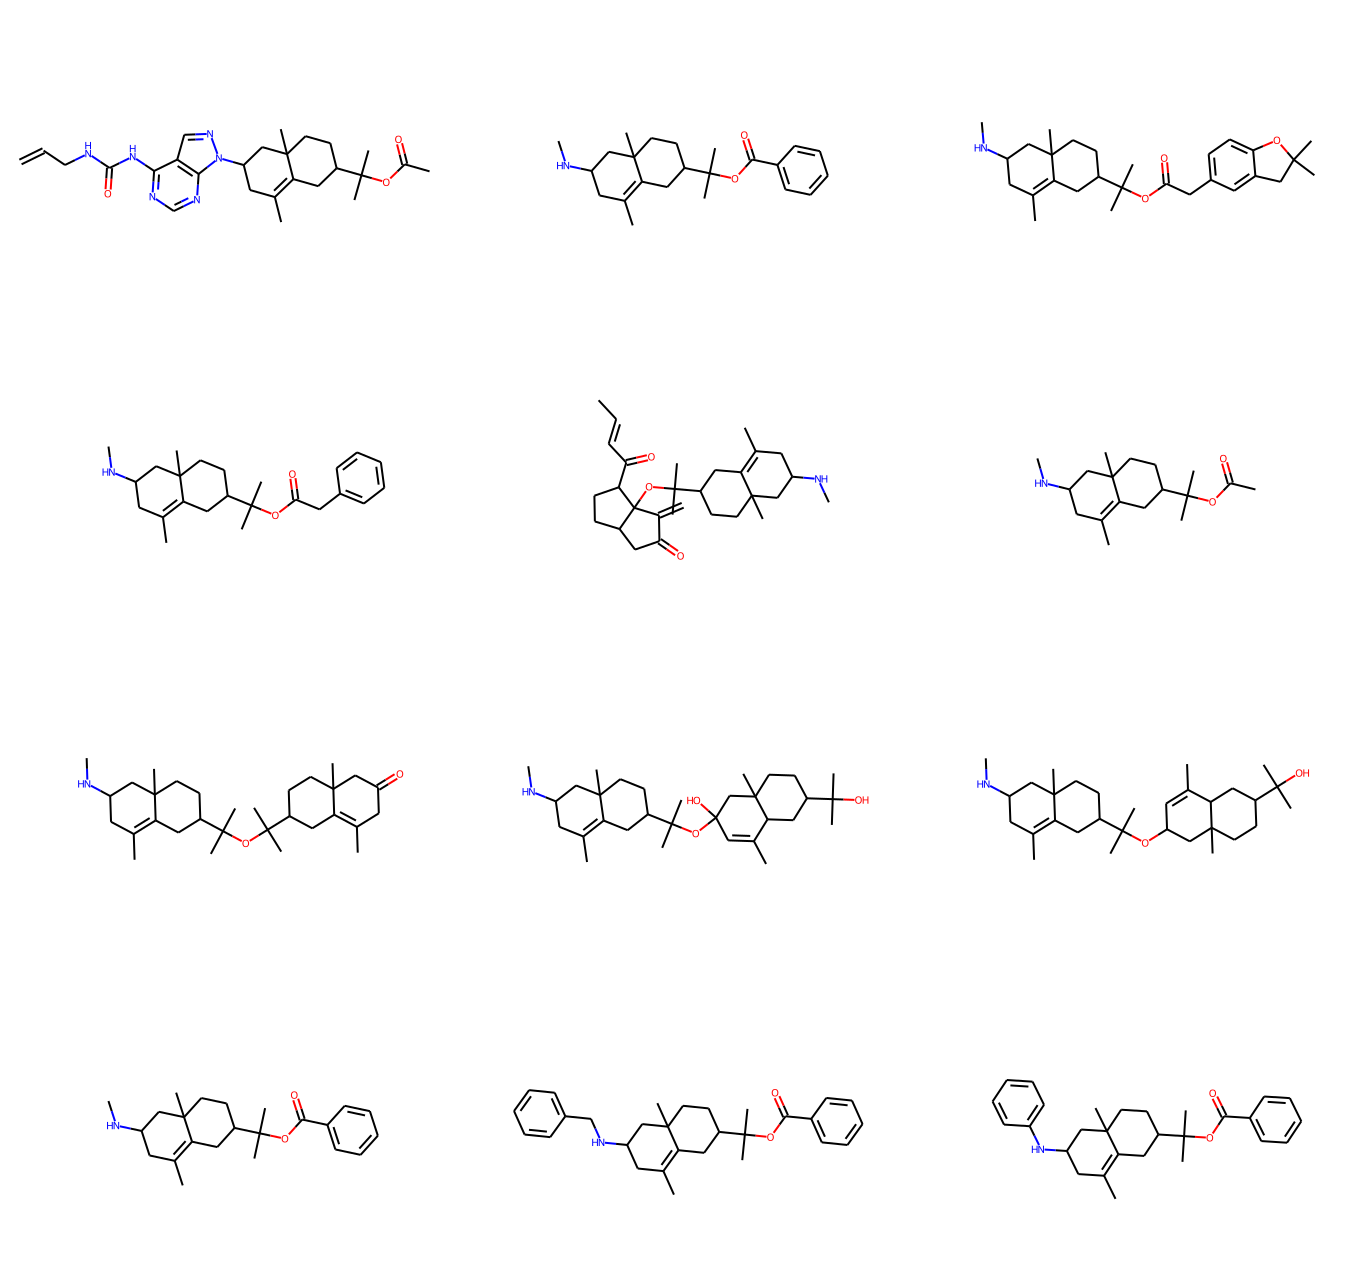

In [7]:
# Draw first 12 enumerated products
products = []
with open('/home/nubar/Downloads/Internship_Chemoinfo/03_synthon/outputs/test_extended_enumeration/FinalOut_allEnumeratedCompounds_DuplicatesCanBePresent.smi') as f:
    for line in f:
        smi = line.strip().split()[0]
        mol = Chem.MolFromSmiles(smi)
        if mol:
            products.append(mol)

print(f'Total enumerated products: {len(products)}')
print('Showing first 12:\n')

img = MolsToGridImage(products[:12], molsPerRow=3, subImgSize=(450, 320))
out_path = '/home/nubar/Downloads/Internship_Chemoinfo/04_results/enumerated_products.png'
with open(out_path, 'wb') as f:
    f.write(img.data)
display(img)

In [8]:
# MW distribution of products
mws = [Descriptors.MolWt(mol) for mol in products]
print(f"MW distribution of enumerated products:")
print(f"  Min MW:  {min(mws):.1f}")
print(f"  Max MW:  {max(mws):.1f}")
print(f"  Mean MW: {sum(mws)/len(mws):.1f}")
print(f"\nProducts with MW <= 500 (Ro5 compliant range): {sum(1 for mw in mws if mw <= 500)}")
print(f"Products with MW <= 300 (drug fragment range):  {sum(1 for mw in mws if mw <= 300)}")

MW distribution of enumerated products:
  Min MW:  291.4
  Max MW:  499.7
  Mean MW: 434.2

Products with MW <= 500 (Ro5 compliant range): 108
Products with MW <= 300 (drug fragment range):  5


In [9]:
# Show small products — likely from simple BB combinations
print("=== SMALL PRODUCTS MW < 300 (likely involving simple reference BBs) ===\n")
with open('/home/nubar/Downloads/Internship_Chemoinfo/03_synthon/outputs/test_extended_enumeration/FinalOut_allEnumeratedCompounds_DuplicatesCanBePresent.smi') as f:
    for line in f:
        smi = line.strip().split()[0]
        mol = Chem.MolFromSmiles(smi)
        if mol:
            mw = Descriptors.MolWt(mol)
            if mw < 300:
                print(f"SMILES: {smi}")
                print(f"MW:     {mw:.1f} Da")
                print("-" * 50)

=== SMALL PRODUCTS MW < 300 (likely involving simple reference BBs) ===

SMILES: CNC1CC(C)=C2CC(C(C)(C)OC(C)=O)CCC2(C)C1
MW:     293.5 Da
--------------------------------------------------
SMILES: CNC1CC(C)=C2CC(C(C)(C)OC(C)=O)CCC2(C)C1
MW:     293.5 Da
--------------------------------------------------
SMILES: CN=C1CC(C)=C2CC(C(C)(C)OC(C)=O)CCC2(C)C1
MW:     291.4 Da
--------------------------------------------------
SMILES: CN=C1CC(C)=C2CC(C(C)(C)OC(C)=O)CCC2(C)C1
MW:     291.4 Da
--------------------------------------------------
SMILES: CN=C1C=C(C)C2CC(C(C)(C)OC(C)=O)CCC2(C)C1
MW:     291.4 Da
--------------------------------------------------
